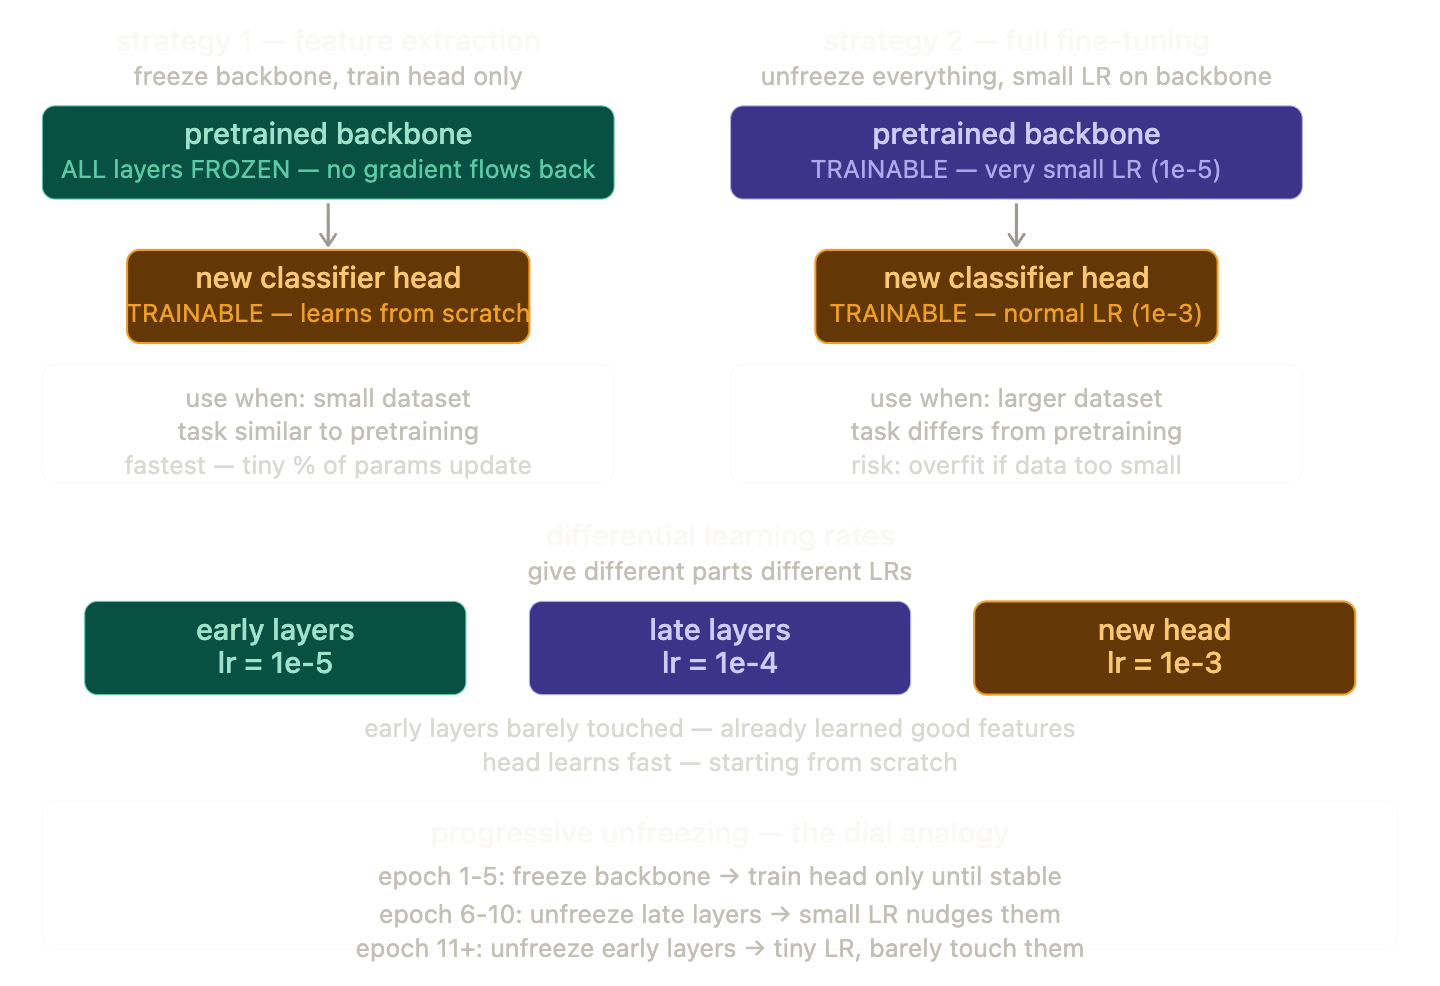

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import copy

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f"Using device: {device}")

class Backbone(nn.Module):
    """
    Multi-layer feature extractor.
    Deliberately deep so transfer learning effects are visible.
    early_layers → general features
    late_layers  → task-specific features
    """
    def __init__(self, input_dim=32, hidden=128, feature_dim=64):
        super().__init__()
        # Early layers — learning general features
        self.early_layers = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
        )
        # Late layers — more task specific
        self.late_layers = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Linear(hidden, feature_dim),
            nn.LayerNorm(feature_dim),
            nn.ReLU(),
        )
    
    def forward(self, x):
        x = self.early_layers(x)
        x = self.late_layers(x)
        return x

    def get_features(self, x):
        """Return intermediate features for visualization."""
        early = self.early_layers(x)
        late  = self.late_layers(early)
        return early, late

torch.manual_seed(0)

N_PRETRAIN  = 2000
X_pretrain  = torch.randn(N_PRETRAIN, 32).to(device)
# Task A: 6-class classification based on feature patterns
y_pretrain  = (X_pretrain[:, :6].argmax(dim=1))

backbone      = Backbone().to(device)
pretrain_head = nn.Linear(64, 6).to(device)

optimizer = optim.Adam(
    list(backbone.parameters()) +
    list(pretrain_head.parameters()), lr=0.005
)
criterion = nn.CrossEntropyLoss()

print("Pretraining backbone on Task A (large dataset)...")
pretrain_losses = []
for epoch in range(60):
    optimizer.zero_grad()
    feats = backbone(X_pretrain)
    loss  = criterion(pretrain_head(feats), y_pretrain)
    loss.backward()
    optimizer.step()
    pretrain_losses.append(loss.item())

preds_A    = pretrain_head(backbone(X_pretrain)).argmax(dim=1)
pretrain_acc = (preds_A == y_pretrain).float().mean().item()
print(f"  Pretraining complete — Acc: {pretrain_acc:.3f}, "
      f"Loss: {pretrain_losses[-1]:.3f}")

Using device: mps
Pretraining backbone on Task A (large dataset)...
  Pretraining complete — Acc: 1.000, Loss: 0.001


In [9]:
# Small Task B dataset — binary classification, only 120 samples
torch.manual_seed(7)
N_B    = 120
X_B    = torch.randn(N_B, 32).to(device)
y_B    = ((X_B[:, 0] * 2 + X_B[:, 2] - X_B[:, 4] +
           torch.randn(N_B).to(device) * 0.3) > 0).long()

split    = int(0.8 * N_B)
X_B_tr, y_B_tr = X_B[:split], y_B[:split]
X_B_vl, y_B_vl = X_B[split:], y_B[split:]

print(f"\nTask B dataset: {N_B} samples "
      f"({split} train, {N_B - split} val)")
print(f"Class balance: {y_B.sum().item()} positive, "
      f"{N_B - y_B.sum().item()} negative")

def build_transfer_model(strategy, backbone):
    """Build model for Task B using specified transfer strategy."""
    bb   = copy.deepcopy(backbone)
    head = nn.Linear(64, 2).to(device)

    if strategy == 'scratch':
        # Re-initialize backbone — no pretrained knowledge
        for module in bb.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)              # 
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
        for p in bb.parameters():
            p.requires_grad = True

    elif strategy == 'frozen':
        # Freeze entire backbone — only head trains
        for p in bb.parameters():
            p.requires_grad = False

    elif strategy == 'finetune_last':
        # Freeze early layers, unfreeze late layers + head
        for p in bb.early_layers.parameters():
            p.requires_grad = False
        for p in bb.late_layers.parameters():
            p.requires_grad = True

    elif strategy == 'finetune_all':
        # Unfreeze everything — differential LRs applied at optimizer
        for p in bb.parameters():
            p.requires_grad = True

    return bb, head

def build_optimizer(strategy, bb, head):
    """Different optimizer configs per strategy."""
    if strategy == 'scratch':
        return optim.Adam(
            list(bb.parameters()) + list(head.parameters()), lr=0.005
        )
    elif strategy == 'frozen':
        return optim.Adam(head.parameters(), lr=0.005)

    elif strategy == 'finetune_last':
        return optim.Adam([
            {'params': bb.late_layers.parameters(), 'lr': 0.0005},
            {'params': head.parameters(),           'lr': 0.005},
        ])
    elif strategy == 'finetune_all':
        # Differential LRs — earlier layers get smaller LR
        return optim.Adam([
            {'params': bb.early_layers.parameters(), 'lr': 0.00005},
            {'params': bb.late_layers.parameters(),  'lr': 0.0005},
            {'params': head.parameters(),            'lr': 0.005},
        ])

def count_trainable(bb, head):
    total     = sum(p.numel() for p in list(bb.parameters()) +
                    list(head.parameters()))
    trainable = sum(p.numel() for p in list(bb.parameters()) +
                    list(head.parameters()) if p.requires_grad)
    return trainable, total

def train_strategy(strategy, backbone, epochs=60):
    bb, head  = build_transfer_model(strategy, backbone)
    optimizer = build_optimizer(strategy, bb, head)
    criterion = nn.CrossEntropyLoss()

    trainable, total = count_trainable(bb, head)
    print(f"  [{strategy:15s}] Trainable: "
          f"{trainable:,} / {total:,} "
          f"({100*trainable/total:.1f}%)")

    train_losses, val_accs = [], []

    for epoch in range(epochs):
        bb.train()
        head.train()

        optimizer.zero_grad()
        feats = bb(X_B_tr)
        loss  = criterion(head(feats), y_B_tr)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        bb.eval()
        head.eval()
        with torch.no_grad():
            preds   = head(bb(X_B_vl)).argmax(dim=1)
            val_acc = (preds == y_B_vl).float().mean().item()
        val_accs.append(val_acc)

    return train_losses, val_accs

strategies = ['scratch', 'frozen', 'finetune_last', 'finetune_all']
results    = {}

print("\nTraining all strategies on small Task B dataset...")
for s in strategies:
    tl, va    = train_strategy(s, backbone, epochs=60)
    results[s] = {'loss': tl, 'acc': va}
    print(f"    → Final val acc: {va[-1]:.3f} | "
          f"Best val acc: {max(va):.3f}")



Task B dataset: 120 samples (96 train, 24 val)
Class balance: 61 positive, 59 negative

Training all strategies on small Task B dataset...
  [scratch        ] Trainable: 46,530 / 46,530 (100.0%)
    → Final val acc: 0.875 | Best val acc: 0.875
  [frozen         ] Trainable: 130 / 46,530 (0.3%)
    → Final val acc: 0.625 | Best val acc: 0.792
  [finetune_last  ] Trainable: 25,282 / 46,530 (54.3%)
    → Final val acc: 0.875 | Best val acc: 0.875
  [finetune_all   ] Trainable: 46,530 / 46,530 (100.0%)
    → Final val acc: 0.875 | Best val acc: 0.875


In [10]:
print("\n── Progressive Unfreezing ──────────────────────────")

bb_prog, head_prog = build_transfer_model('frozen', backbone)
optimizer_prog = optim.Adam(head_prog.parameters(), lr=0.005)
criterion      = nn.CrossEntropyLoss()

prog_losses = []
prog_accs   = []

for epoch in range(60):
    # Phase 1 (0-19): frozen backbone, train head only
    if epoch == 20:
        print(f"  Epoch 20 — Unfreezing late layers...")
        for p in bb_prog.late_layers.parameters():
            p.requires_grad = True
        optimizer_prog = optim.Adam([
            {'params': bb_prog.late_layers.parameters(), 'lr': 0.0005},
            {'params': head_prog.parameters(),           'lr': 0.005},
        ])

    # Phase 2 (20-39): late layers + head
    elif epoch == 40:
        print(f"  Epoch 40 — Unfreezing early layers...")
        for p in bb_prog.early_layers.parameters():
            p.requires_grad = True
        optimizer_prog = optim.Adam([
            {'params': bb_prog.early_layers.parameters(), 'lr': 0.00005},
            {'params': bb_prog.late_layers.parameters(),  'lr': 0.0005},
            {'params': head_prog.parameters(),            'lr': 0.005},
        ])

    # Phase 3 (40-59): everything unfrozen
    bb_prog.train()
    head_prog.train()
    optimizer_prog.zero_grad()
    loss = criterion(head_prog(bb_prog(X_B_tr)), y_B_tr)
    loss.backward()
    optimizer_prog.step()
    prog_losses.append(loss.item())

    bb_prog.eval()
    head_prog.eval()
    with torch.no_grad():
        preds   = head_prog(bb_prog(X_B_vl)).argmax(dim=1)
        val_acc = (preds == y_B_vl).float().mean().item()
    prog_accs.append(val_acc)

print(f"  Progressive unfreezing — Best val acc: {max(prog_accs):.3f}")


── Progressive Unfreezing ──────────────────────────
  Epoch 20 — Unfreezing late layers...
  Epoch 40 — Unfreezing early layers...
  Progressive unfreezing — Best val acc: 0.875


In [11]:
from sklearn.decomposition import PCA

scratch_bb, _ = build_transfer_model('scratch', backbone)

pretrained_bb = copy.deepcopy(backbone)
for p in pretrained_bb.parameters():
    p.requires_grad = False

pretrained_bb.eval()
scratch_bb.eval()

with torch.no_grad():
    feat_pretrained = pretrained_bb(X_B).cpu().numpy()
    feat_scratch    = scratch_bb(X_B).cpu().numpy()

labels = y_B.cpu().numpy()

# PCA to 2D
pca             = PCA(n_components=2)
feat_pre_2d     = pca.fit_transform(feat_pretrained)
feat_scratch_2d = pca.fit_transform(feat_scratch)

You can't plot 64-dimensional space. PCA compresses 64 dimensions down to 2 by finding the two directions that capture the most variance — the most "spread" in the data.

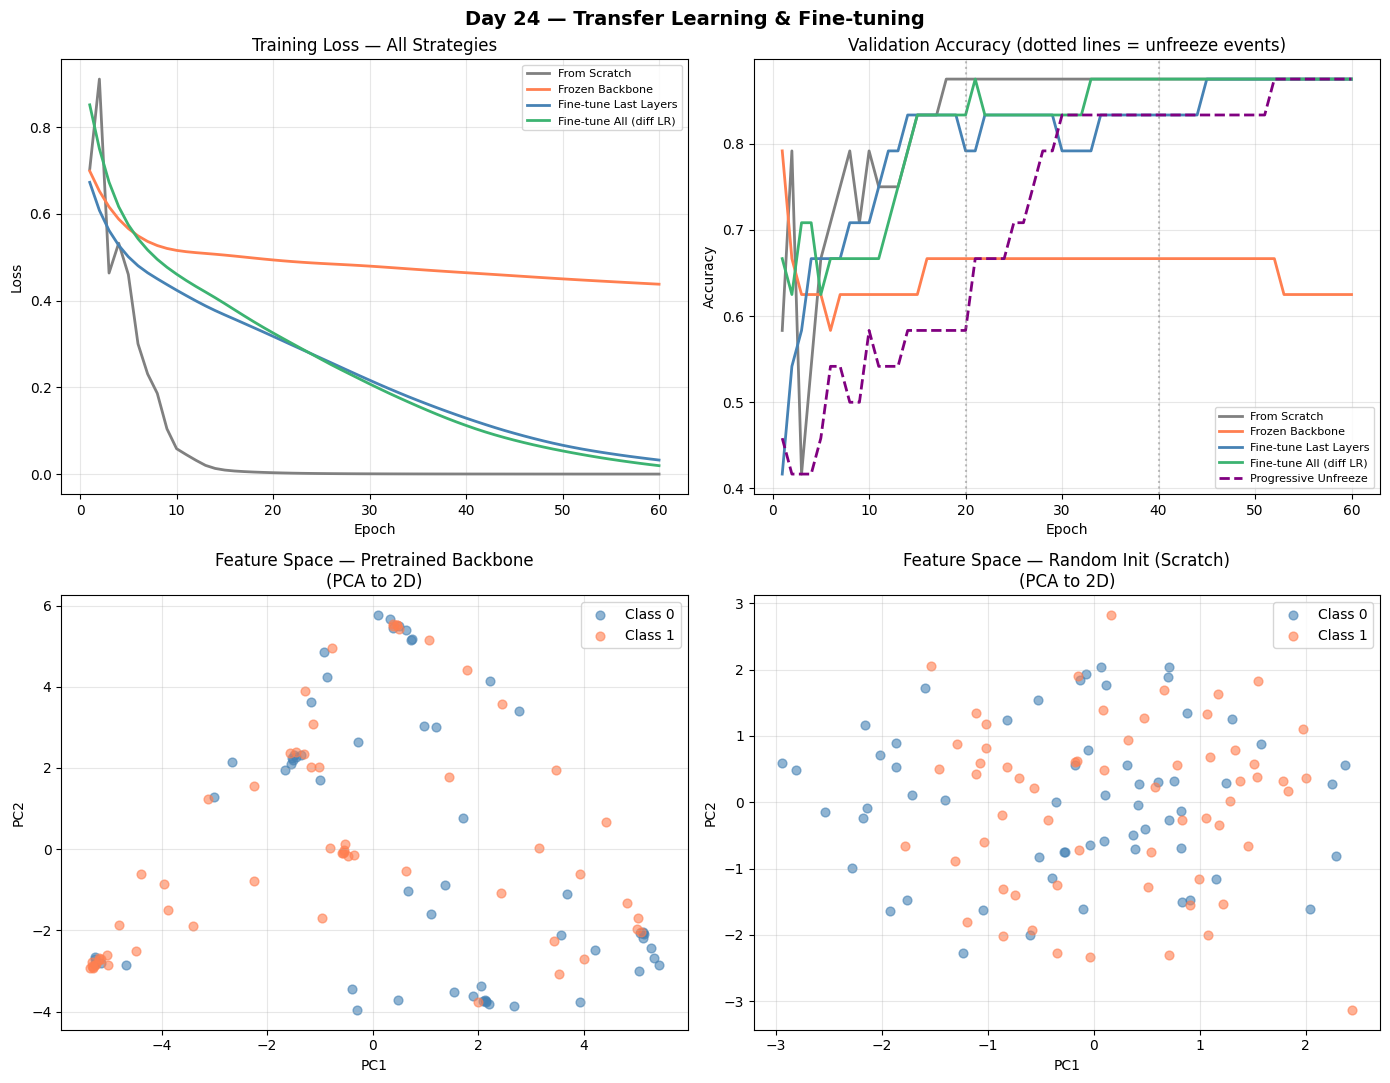

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Day 24 — Transfer Learning & Fine-tuning',
             fontsize=14, fontweight='bold')

colors_map = {
    'scratch':       'gray',
    'frozen':        'coral',
    'finetune_last': 'steelblue',
    'finetune_all':  'mediumseagreen'
}
labels_map = {
    'scratch':       'From Scratch',
    'frozen':        'Frozen Backbone',
    'finetune_last': 'Fine-tune Last Layers',
    'finetune_all':  'Fine-tune All (diff LR)'
}
epochs_r = range(1, 61)

# Training loss
for s in strategies:
    axes[0, 0].plot(epochs_r, results[s]['loss'],
                    label=labels_map[s],
                    color=colors_map[s], linewidth=2)
axes[0, 0].set_title('Training Loss — All Strategies')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Validation accuracy + progressive unfreezing
for s in strategies:
    axes[0, 1].plot(epochs_r, results[s]['acc'],
                    label=labels_map[s],
                    color=colors_map[s], linewidth=2)
axes[0, 1].plot(epochs_r, prog_accs,
                label='Progressive Unfreeze',
                color='purple', linewidth=2, linestyle='--')
axes[0, 1].axvline(x=20, color='gray', linestyle=':', alpha=0.5)
axes[0, 1].axvline(x=40, color='gray', linestyle=':', alpha=0.5)
axes[0, 1].set_title('Validation Accuracy (dotted lines = unfreeze events)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

# Feature space — pretrained
class_colors = ['steelblue', 'coral']
for cls in [0, 1]:
    mask = labels == cls
    axes[1, 0].scatter(feat_pre_2d[mask, 0], feat_pre_2d[mask, 1],
                       c=class_colors[cls], label=f'Class {cls}',
                       alpha=0.6, s=40)
axes[1, 0].set_title('Feature Space — Pretrained Backbone\n(PCA to 2D)')
axes[1, 0].set_xlabel('PC1')
axes[1, 0].set_ylabel('PC2')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Feature space — scratch
for cls in [0, 1]:
    mask = labels == cls
    axes[1, 1].scatter(feat_scratch_2d[mask, 0], feat_scratch_2d[mask, 1],
                       c=class_colors[cls], label=f'Class {cls}',
                       alpha=0.6, s=40)
axes[1, 1].set_title('Feature Space — Random Init (Scratch)\n(PCA to 2D)')
axes[1, 1].set_xlabel('PC1')
axes[1, 1].set_ylabel('PC2')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


The PCA plots are the visual explanation for why fine-tuning beats frozen — the pretrained features have structure but it's not perfectly aligned with Task B. Fine-tuning lets the backbone adjust that structure slightly. Frozen can't adjust, scratch has no structure at all.